# Exam

> Data: **2020-01-28**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il datataset weather_train.csv (preso da [Kaggle](https://www.kaggle.com/nicholasjhana/energy-consumption-generation-prices-and-weather)) contiene dati relativi a rilevazioni meteo registrate in città spagnole una volta al giorno secondo il seguente schema:

- `dt_iso`
- `city_name`
- `temp`
- `temp_min`
- `temp_max`
- `pressure`
- `humidity`
- `wind_speed`
- `wind_deg`
- `rain_1h`
- `rain_3h`
- `snow_3h`
- `clouds_all`
- `weather_id`
- `weather_main'`
- `weather_description`
- `weather_icon`

Il dataset è costituito da attributi con valori numerici e categorici. L'obiettivo è quello di prevedere il tempo complessivo di una giornata (valore della feature
`weather_main`) sulla base degli altri parametri.

Note: Il file csv che si trova al [link](http://bit.ly/wea_2020).

### Imports

In [ ]:
!curl -sLo dataset.zip "http://sparc20.ing.unimo.it/~guerra/esamiBDA/weather.zip"
!unzip -o dataset.zip
!mv weather_train.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: class.csv               
  inflating: weather_test.csv        
  inflating: weather_train.csv       


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2016-05-26 09:00:00+02:00,Bilbao,288.420,285.150,290.930,1012,93,0,0,0.0,0.0,0.0,75,803,clouds,broken clouds,04d
1,2016-07-16 10:00:00+02:00,Madrid,299.037,299.037,299.037,961,44,2,83,0.0,0.0,0.0,0,800,clear,sky is clear,01d
2,2018-06-03 05:00:00+02:00,Madrid,285.150,285.150,285.150,1017,100,0,0,0.0,0.0,0.0,56,803,clouds,broken clouds,04n
3,2018-10-19 10:00:00+02:00,Valencia,289.150,289.150,289.150,1011,100,4,320,0.9,0.0,0.0,75,521,rain,shower rain,09d
4,2017-11-25 07:00:00+01:00,Seville,279.940,279.150,281.150,1019,81,0,50,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158131 entries, 0 to 158130
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               158131 non-null  object 
 1   city_name            158131 non-null  object 
 2   temp                 158131 non-null  float64
 3   temp_min             158131 non-null  float64
 4   temp_max             158131 non-null  float64
 5   pressure             158131 non-null  int64  
 6   humidity             158131 non-null  int64  
 7   wind_speed           158131 non-null  int64  
 8   wind_deg             158131 non-null  int64  
 9   rain_1h              158131 non-null  float64
 10  rain_3h              158131 non-null  float64
 11  snow_3h              158131 non-null  float64
 12  clouds_all           158131 non-null  int64  
 13  weather_id           158131 non-null  int64  
 14  weather_main         158131 non-null  object 
 15  weather_descripti

#### Instances

In [ ]:
df.shape

(158131, 17)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["weather_main"].value_counts()

,count
weather_main,
clear,77750
clouds,64130
rain,16251


<Axes: >

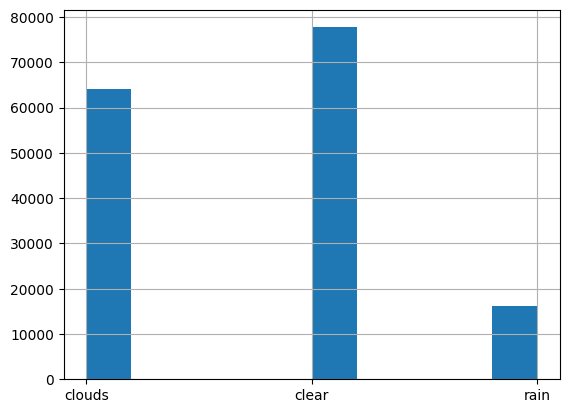

In [ ]:
df["weather_main"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire?

In [ ]:
df.shape[0]

158131

> Il dataset contiene 158131 istanze.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

> Il dataset è completo, non contiene nessun missing values.

In [ ]:
df["weather_main"].value_counts()

,count
weather_main,
clear,77750
clouds,64130
rain,16251


> Il dataset non è bilanciato, in quanto la classe `rain` è sotto rappresentata.

---

### Domanda 02 (Punti 1)

Le rilevazioni con pressione e umidità uguale a 0 sono irreali. Quante sono queste rilevazioni? Eliminarle dal dataset.

In [ ]:
mask_zero_pressure = df["pressure"] == 0
mask_zero_humidity = df["humidity"] == 0
print("Pressure & Humidity:", df[mask_zero_pressure & mask_zero_humidity].shape[0])
print("Pressure | Humidity:", df[mask_zero_pressure | mask_zero_humidity].shape[0])

Pressure & Humidity: 0
Pressure | Humidity: 61


> Le rilevazioni con pressione E umidità pari a 0 non sono presenti nel dataset. Le rilevazioni con pressione O umidità pari a 0 sono 61 nel dataset.

In [ ]:
df.drop(df[mask_zero_pressure | mask_zero_humidity].index, inplace=True)

---

### Domanda 03 (Punti 4)

Analizzare la temperatura massima rilevata. Valutare se la distribuzione dei valori assume un andamento simile a una gaussiana. Considerare poi le rilevazioni che si collocano all’interno del 5% delle temperature più alte. Le città sono equamente presenti in quella fascia di rilevazioni? Come è il tempo complessivo nei giorni in cui la temperatura massima è in quella fascia per ogni città?

<Axes: ylabel='Frequency'>

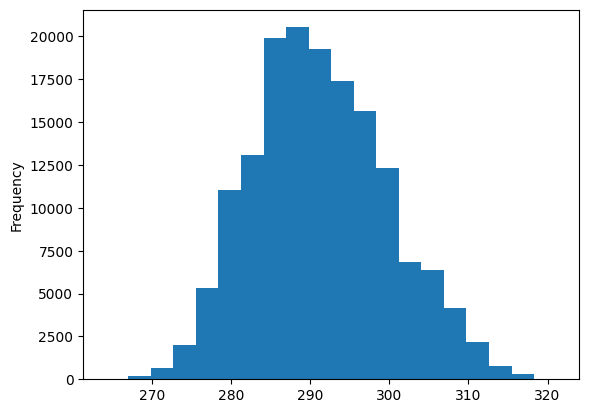

In [ ]:
df["temp_max"].plot(kind="hist", bins=20)

> Si, le rilevazioni delle temperature massime, `temp_max`, mostrano una distribuzione simile ad una Gaussiana.

In [ ]:
max_5_perc = df["temp_max"].quantile(0.95)
temp_max_5_perc = df[df["temp_max"] > max_5_perc]
temp_max_5_perc.groupby("city_name")["temp_max"].count().sort_values(ascending=False)

,temp_max
city_name,
Seville,4557
Madrid,1804
Barcelona,539
Valencia,531
Bilbao,346


In [ ]:
df["city_name"].value_counts()

,count
city_name,
Valencia,32608
Barcelona,32353
Madrid,31593
Seville,31103
Bilbao,30413


> No, seppur nel dataset le città presenti siano equamente rappresentate, le città con il 5% di temperature massime non sono equamente presenti, con Siviglia la principale città seguita da Madrid.

In [ ]:
temp_max_5_perc.groupby(["city_name", "weather_main"])["dt_iso"].count().unstack()

weather_main,clear,clouds,rain
city_name,,,
Barcelona,267,246,26
Bilbao,195,148,3
Madrid,1427,363,14
Seville,3856,581,120
Valencia,279,250,2


> Possiamo notare che nelle città presenti nel 5% delle temperature massime hanno avuto prevalentemente giornate `clear` e `clouds`, con Siviglia e Madrid le quali prevalgono giornate `clear`.

---

### Domanda 04 (Punti 2)

Verificare se quando nevica la temperatura sia prossima alla temperatura di congelamento. (NOTA: il dataset riporta i valori in Kelvin)

In [ ]:
mask_snow = df["snow_3h"] > 0
df[mask_snow].groupby("city_name")["temp"].mean() - 273.15

,temp
city_name,
Bilbao,2.803357
Madrid,7.652000
Valencia,7.214286


In [ ]:
df[mask_snow]["temp"].mean() - 273.15

np.float64(2.968751012731502)

> In media, le temperature di quando ha nevicato è di quasi 3 °C, quindi sì, sono vicine allo 0 °C. Considerando solo Madrid e Valencia, le temperature medie durante le nevicate sono di 7,5 °C, probabilmente ci sono state molte meno nevicate in queste città che a Bilbao.

### Domanda 05 (Punti 2)

Confrontare l’escursione termica media (`temp_max - temp_min`) registrata nei giorni in cui nevica, con quella delle giornate che sono all’interno del 5% delle temperature più alte

In [ ]:
df["delta_temp"] = df["temp_max"] - df["temp_min"]
delta_temp_snow = df[df["snow_3h"] > 0]["delta_temp"]
delta_temp_max_5_perc = df[df["temp_max"] > max_5_perc]["delta_temp"]

print("Delta snow:", delta_temp_snow.mean())
print("Delta temperature max 5%:", delta_temp_max_5_perc.mean())

Delta snow: 0.0
Delta temperature max 5%: 7.65067635334962


> Il delta delle temperature di quando è nevicato è 0, mentre il delta per il 5% delle temperature massime è di poco più di 5 °K.

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire il valore di `weather_main` sulla base degli attributi presenti nel dataset. Dividere il dataset in modo che 2/3 degli elementi siano contenuti in un nuovo dataset "train" e 1/3 nel dataset "test".

Eliminare gli attributi `[dt_iso, city_name, weather_description, weather_icon, weather_id, clouds_all]`. Convertire l’attributo `weather_main` in numerico in maniera opportuna.

Allenare il train con il modello Decision Tree e valutare l'accuracy ottenuta calcolata sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello Logistic Regression. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione anche l’analisi della confusion matrix.

In [ ]:
df = pd.read_csv("dataset.csv")
df.drop(df[mask_zero_pressure | mask_zero_humidity].index, inplace=True)
df.drop(["dt_iso", "city_name", "weather_description", "weather_icon", "weather_id", "clouds_all"], axis=1, inplace=True)
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df["weather_main"] = encoder.fit_transform(df[["weather_main"]])
df.head()

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,weather_main
0,288.420,285.150,290.930,1012,93,0,0,0.0,0.0,0.0,1
1,299.037,299.037,299.037,961,44,2,83,0.0,0.0,0.0,0
2,285.150,285.150,285.150,1017,100,0,0,0.0,0.0,0.0,1
3,289.150,289.150,289.150,1011,100,4,320,0.9,0.0,0.0,2
4,279.940,279.150,281.150,1019,81,0,50,0.0,0.0,0.0,0


In [ ]:
X, y = df.drop("weather_main", axis=1), df["weather_main"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, stratify=y, random_state=0)

In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "LogisticRegression": LogisticRegression(max_iter=500, n_jobs=-1, random_state=0),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1-score:", f1_score(y_train, y_pred_train, average="macro"))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1-score:", f1_score(y_test, y_pred_test, average="macro"))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Accuracy: 0.996982349591953
    F1-score: 0.9977358309399905
[[51785    28     0]
 [  290 42451     0]
 [    0     0 10826]]
------------------------------
TEST
    Accuracy: 0.7031315240083508
    F1-score: 0.7773055919001316
[[18125  7781     0]
 [ 7861 13510     0]
 [    0     0  5413]]

LogisticRegression
TRAIN
    Accuracy: 0.5799392674131714
    F1-score: 0.5090644419384754
[[36410 14941   462]
 [19674 22098   969]
 [ 2351  5869  2606]]
------------------------------
TEST
    Accuracy: 0.5795596887454925
    F1-score: 0.5102563892007096
[[18208  7456   242]
 [ 9914 11006   451]
 [ 1157  2933  1323]]



> Il modello `DecisionTree` ha performance discrete, del 77% sul dataset di test, con errori principalmente nella predizione della classe 0 e 1, le quali vengono predette inversamente, `True: 0 -> Predict 1`, `True: 1 -> Predict 0`.
>
> Il modello `LogisticRegression` ottiene performance scadenti, intorno al 50%. Probabilmente avrebbe bisogno di più iterazioni per ottenere performance migliori.

---

### Domanda 02 (Punti 1)

Confrontare l'accuratezza ottenuta nel punto precedente con l'accuratezza che si ottiene con un una 10 Fold cross validation.

In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10)
    print(name)
    print("=" * 30)
    print("Score mean:", scores.mean())
    print("Scores:", scores)
    print("=" * 30)
    print()

DecisionTree
Score mean: 0.7099449610931866
Scores: [0.71253242 0.70475106 0.70955906 0.71417726 0.71392421 0.71088758
 0.70854685 0.71101411 0.70702853 0.70702853]

LogisticRegression
Score mean: 0.5872904409438857
Scores: [0.57930031 0.60239135 0.58227368 0.58056557 0.5901183  0.58347568
 0.577782   0.59429367 0.58739799 0.59530588]



> Le performance di entrambi i modelli dopo aver effettuato un 10 fold cross validation ottengono performance in linea con quelle viste nel precedente punto.

---

### Domanda 03 (Punti 3)

Utilizzare la funzione Normalizer per normalizzare i valori del dataset e confrontare se l'accuratezza ottenuta con il Decision Tree Classifier migliora.

In [ ]:
normalizer = Normalizer()
X, y = df.drop("weather_main", axis=1), df["weather_main"]
X = pd.DataFrame(normalizer.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, stratify=y, random_state=0)

In [ ]:
decision_tree = models["DecisionTree"]
decision_tree.fit(X_train, y_train)
y_pred_train = decision_tree.predict(X_train)
y_pred_test = decision_tree.predict(X_test)
print("TRAIN")
print("    Accuracy:", accuracy_score(y_train, y_pred_train))
print("    F1-score:", f1_score(y_train, y_pred_train, average="macro"))
print(confusion_matrix(y_train, y_pred_train))
print("TEST")
print("    Accuracy:", accuracy_score(y_test, y_pred_test))
print("    F1-score:", f1_score(y_test, y_pred_test, average="macro"))
print(confusion_matrix(y_test, y_pred_test))

TRAIN
    Accuracy: 0.996982349591953
    F1-score: 0.9977358309399905
[[51785    28     0]
 [  290 42451     0]
 [    0     0 10826]]
TEST
    Accuracy: 0.6839817802239514
    F1-score: 0.7629236726651575
[[17629  8277     0]
 [ 8374 12997     0]
 [    0     0  5413]]


> No, il modello non sembra migliorare, ottiene metriche molto simili a quelle viste precedentemente.

---

### Domanda 04 (Punti 2 + 2)

Creare una pipeline con trasformatori PCA (si scelgano 5 attributi) e poi Normalizer. Si usi come modello il Decision Tree Classifier. (2 punti ulteriori se gli attributi della PCA sono aggiunti agli attributi del dataset)

In [ ]:
df = pd.read_csv("dataset.csv")
df.drop(df[mask_zero_pressure | mask_zero_humidity].index, inplace=True)
df.drop(["dt_iso", "city_name", "weather_description", "weather_icon", "weather_id", "clouds_all"], axis=1, inplace=True)
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df["weather_main"] = encoder.fit_transform(df[["weather_main"]])

In [ ]:
X, y = df.drop("weather_main", axis=1), df["weather_main"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, stratify=y, random_state=0)

In [ ]:
pca = PCA(n_components=5, random_state=0)

pipeline = Pipeline(
    steps=[
        ("pca", pca),
        ("normalizer", normalizer),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('pca', PCA(n_components=5, random_state=0)),
                ('normalizer', Normalizer()),
                ('decision_tree', DecisionTreeClassifier(random_state=0))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5720250521920668
F1-score: 0.5195777420410312
[[16669  7807  1430]
 [ 7944 11380  2047]
 [ 1385  1937  2091]]


> Le performance del modello calano drasticamente, come è possibile vedere anche dalla confusion matrix. Il motivo potrebbe essere il numero troppo basso di attributi che vengono utilizzati per il modello, anche se dovrebbero essere le 5 componenti principali.

---

### Domanda 05 (Punti 4)

Utilizzare la funzione di gridSearchCV sulla pipeline per modificare il numero di attributi selezionati dalla PCA e alcuni parametri a piacere del classificatore. Verificare se l'accuratezza che si ottiene con la nuova configurazione supera quella standard ottenuta al punto 1.

In [ ]:
params = {
    "pca__n_components": [5, 8, 10],
    "decision_tree__criterion": ["gini", "entropy", "log_loss"],
    "decision_tree__max_depth": [5, 10, 15],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Best params: {'decision_tree__criterion': 'entropy', 'decision_tree__max_depth': 15, 'pca__n_components': 10}
Best score: 0.6975991649269312
Accuracy: 0.7029417346745113
F1-score: 0.7741788279959744
[[18542  7343    21]
 [ 8214 13143    14]
 [   29    31  5353]]


> Seppur ottenuto i parametri ottimali attraverso il `GridSearchCV`, ovvero `criterion: entroy`, `max_depth: 15` e `n_components: 10`, il modello mostra performance simili a quelle viste precedentemente, anche se con una confusion matrix più varia rispetto alla prima analizzata.

---

### Domanda 06 (Punti 2)

Si verifichi l'accuratezza ottenuta dalla pipeline del punto 4 con il file weather_test. I risultati corretti sono nel file class.csv. Controllare le features presenti nei dataset.

In [ ]:
X, y = pd.read_csv("weather_test.csv"), pd.read_csv("class.csv")

mask_zero_pressure = X["pressure"] == 0
mask_zero_humidity = X["humidity"] == 0
X.drop(X[mask_zero_pressure | mask_zero_humidity].index, inplace=True)
y.drop(y[mask_zero_pressure | mask_zero_humidity].index, inplace=True)
X.drop(["Unnamed: 0", "dt_iso", "city_name", "weather_description", "weather_icon", "weather_id", "clouds_all"], axis=1, inplace=True)
y.drop(["Unnamed: 0"], axis=1, inplace=True)

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, stratify=y, random_state=0)

In [ ]:
best_n_components = grid_search.best_params_["pca__n_components"]
best_criterion = grid_search.best_params_["decision_tree__criterion"]
best_max_depth = grid_search.best_params_["decision_tree__max_depth"]

pca = PCA(n_components=best_n_components, random_state=0)
decision_tree = DecisionTreeClassifier(criterion=best_criterion, max_depth=best_max_depth, random_state=0)

pipeline = Pipeline(
    steps=[
        ("pca", pca),
        ("normalizer", normalizer),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('pca', PCA(n_components=10, random_state=0)),
                ('normalizer', Normalizer()),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=15,
                                        random_state=0))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6504650465046504
F1-score: 0.7187619159185532
[[1131  503   11]
 [ 626  673    9]
 [   5   11  364]]


> Su questo secondo dataset il modello ottiene delle metriche leggermente più basse alla media vista precedentemente.

---

### Domanda 07 (Punti 2)

Si sperimenti una pipeline come quella del punto 4 dove al posto del classificatore si utilizzi un regressore lineare. Il risultato dovrà essere approssimato all’intero per il calcolo dell'accuratezza.

In [ ]:
linear_regressor = LinearRegression()

pipeline = Pipeline(
    steps=[
        ("pca", pca),
        ("normalizer", normalizer),
        ("linear_regressor", linear_regressor),
    ],
)
pipeline

Pipeline(steps=[('pca', PCA(n_components=10, random_state=0)),
                ('normalizer', Normalizer()),
                ('linear_regressor', LinearRegression())])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))

RMSE: 0.5964798515299652


> Il Root Mean Square Error è prossimo allo 0, indicandoci che questo modello non sta lavorando male.